In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
train = pd.read_csv("train.csv")

X = train.drop("class", axis=1)
y = train["class"]

Modelo Ada Boost Básico


In [3]:
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

scores = cross_val_score(
    ada,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("CV Accuracy:", scores.mean())

CV Accuracy: 0.74


Versión con arbol base


In [4]:
base_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

Entrenar y evaluar


In [5]:
ada.fit(X, y)

preds = ada.predict(X)

train_acc = accuracy_score(y, preds)

cv_scores = cross_val_score(
    ada,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Train accuracy:", train_acc)
print("5-Fold CV accuracy:", cv_scores.mean())

Train accuracy: 0.838
5-Fold CV accuracy: 0.7909999999999999


Probamos con distintas combinaciones para Ada Boost, de la cantidad de modelos débiles, cuanto influye cada arbol, la profundidad del arbol base

In [6]:
results = []

for n in [50, 100, 200]:
    for lr in [0.1, 0.5, 1.0]:
        for depth in [1, 2]:

            base = DecisionTreeClassifier(
                max_depth=depth,
                random_state=42
            )

            model = AdaBoostClassifier(
                estimator=base,
                n_estimators=n,
                learning_rate=lr,
                random_state=42
            )

            scores = cross_val_score(
                model,
                X,
                y,
                cv=5,
                scoring='accuracy'
            )

            results.append([
                n,
                lr,
                depth,
                scores.mean()
            ])

results = pd.DataFrame(
    results,
    columns=[
        "n_estimators",
        "learning_rate",
        "depth",
        "cv_accuracy"
    ]
)

print(results.sort_values(
    by="cv_accuracy",
    ascending=False
).head())

    n_estimators  learning_rate  depth  cv_accuracy
13           200            0.1      2        0.801
15           200            0.5      2        0.793
9            100            0.5      2        0.791
7            100            0.1      2        0.791
14           200            0.5      1        0.791


In [11]:
base_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

Probamos con una profundidad mayor, con los mismos parámetros del top 1 de la lista, n_estimators 200, leraning_rate 0.1 y ahora depth 3


In [12]:
ada.fit(X, y)

preds = ada.predict(X)

train_acc = accuracy_score(y, preds)

cv_scores = cross_val_score(
    ada,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Train accuracy:", train_acc)
print("5-Fold CV accuracy:", cv_scores.mean())

Train accuracy: 0.988
5-Fold CV accuracy: 0.799


Aumentamos cantidad de estimadores, para ver si influye con la profundidad del arbol

In [13]:
ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)

In [14]:
ada.fit(X, y)

preds = ada.predict(X)

train_acc = accuracy_score(y, preds)

cv_scores = cross_val_score(
    ada,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Train accuracy:", train_acc)
print("5-Fold CV accuracy:", cv_scores.mean())

Train accuracy: 0.996
5-Fold CV accuracy: 0.8030000000000002


In [15]:
results = []

for n in [300,350]:
    for lr in [0.1, 0.5, 1.0]:
        for depth in [3, 4]:

            base = DecisionTreeClassifier(
                max_depth=depth,
                random_state=42
            )

            model = AdaBoostClassifier(
                estimator=base,
                n_estimators=n,
                learning_rate=lr,
                random_state=42
            )

            scores = cross_val_score(
                model,
                X,
                y,
                cv=5,
                scoring='accuracy'
            )

            results.append([
                n,
                lr,
                depth,
                scores.mean()
            ])

results = pd.DataFrame(
    results,
    columns=[
        "n_estimators",
        "learning_rate",
        "depth",
        "cv_accuracy"
    ]
)

print(results.sort_values(
    by="cv_accuracy",
    ascending=False
).head())

    n_estimators  learning_rate  depth  cv_accuracy
3            300            0.5      4        0.824
9            350            0.5      4        0.818
11           350            1.0      4        0.817
5            300            1.0      4        0.814
7            350            0.1      4        0.811


In [7]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

ada.fit(X, y)

importance = permutation_importance(
    ada,
    X,
    y,
    n_repeats=10,
    random_state=42
)

feature_importance = pd.Series(
    importance.importances_mean,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

yanyfsa    0.0391
bcypgdl    0.0208
pmvpzze    0.0182
qmkchdk    0.0148
eadsvll    0.0147
nriajlz    0.0080
xosgaqd    0.0077
npxvalz    0.0076
aexjkud    0.0071
joshsnx    0.0063
dtype: float64


Importancia de Permutación

Gráfico de importancia 

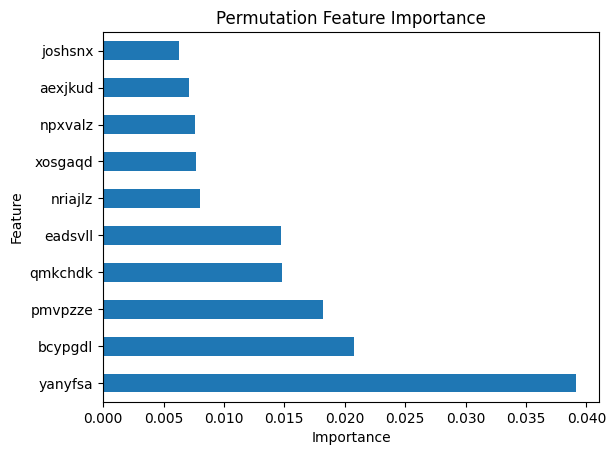

In [9]:
feature_importance.head(10).plot(kind='barh')

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.show()